<a href="https://colab.research.google.com/github/Yarledyzapata/deteccion-enfermedades-en-hojas-de-tomate/blob/main/LeafDisease_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# INSTALACIÓN DE LIBRERÍAS
# ============================================================

!pip install ultralytics -q


In [ ]:
# ============================================================
# VERIFICAR INSTALACIÓN DE ULTRALYTICS / YOLO
# ============================================================

import ultralytics
ultralytics.checks()

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


In [ ]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


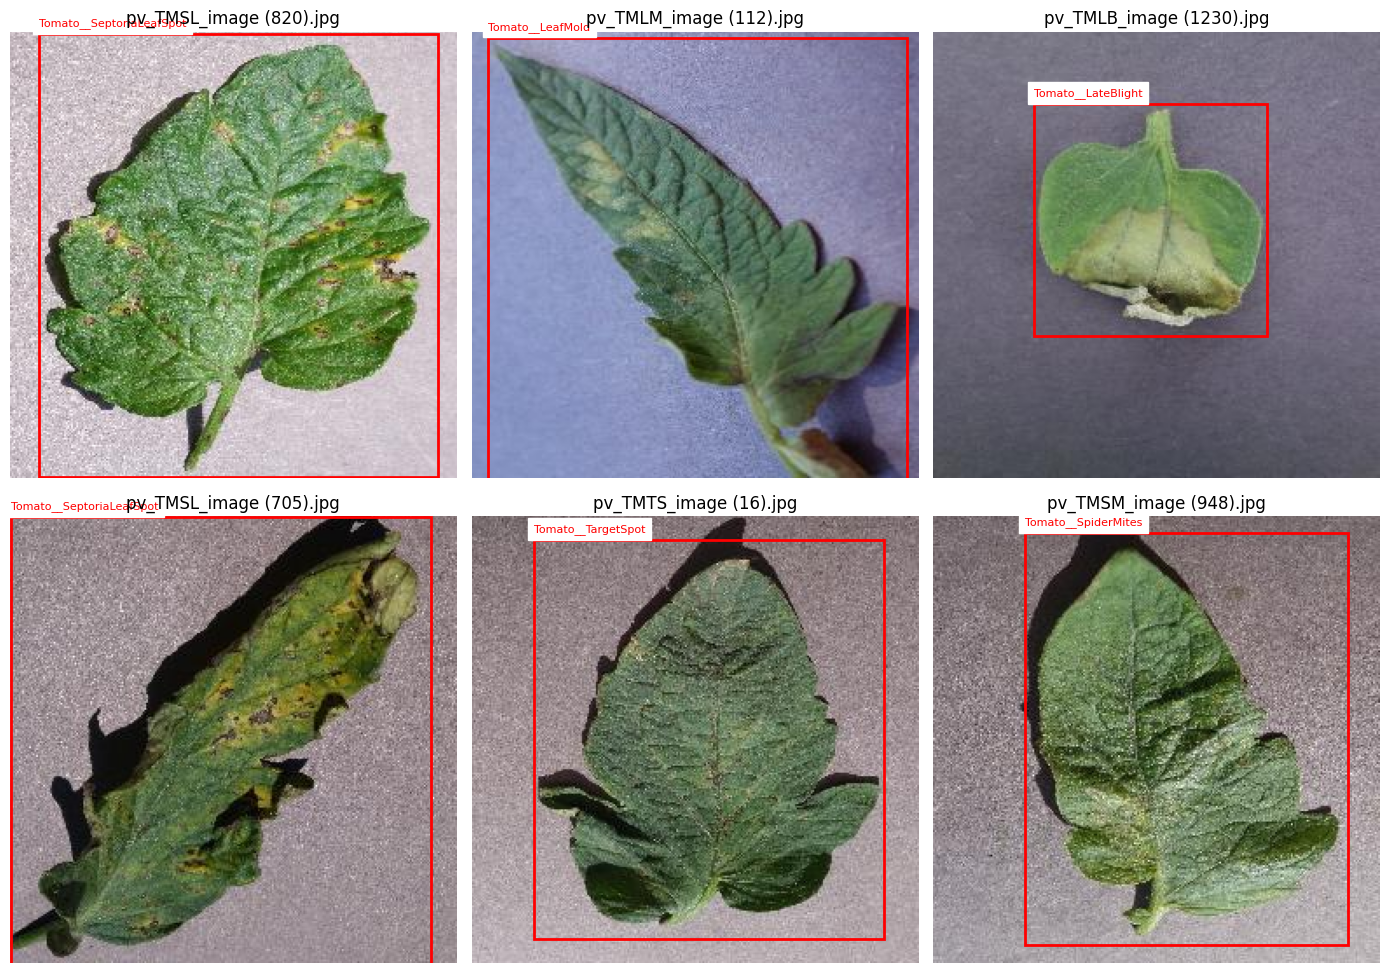

In [ ]:
# ============================================================
# VISUALIZAR IMÁGENES DEL SUBSET CON SUS ETIQUETAS REALES
# ============================================================

import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

class_names = [
    "Tomato__BacterialSpot",
    "Tomato__EarlyBlight",
    "Tomato__Healthy",
    "Tomato__LateBlight",
    "Tomato__LeafMold",
    "Tomato__MosaicVirus",
    "Tomato__SeptoriaLeafSpot",
    "Tomato__SpiderMites",
    "Tomato__TargetSpot",
    "Tomato__YellowLeafCurlVirus"
]

# Cambia aquí si quieres revisar train, val o test
image_paths = read_image_list(test_txt)

sample_images = random.sample(image_paths, min(6, len(image_paths)))

plt.figure(figsize=(14, 10))

for i, img_path in enumerate(sample_images):
    label_path = get_label_path_from_image_path(img_path)

    img = Image.open(img_path).convert("RGB")
    width, height = img.size

    ax = plt.subplot(2, 3, i + 1)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.name[:35])

    lines = label_path.read_text().strip().splitlines()

    for line in lines:
        parts = line.split()

        if len(parts) != 5:
            continue

        class_id = int(parts[0])
        x_center, y_center, box_width, box_height = map(float, parts[1:])

        x_center *= width
        y_center *= height
        box_width *= width
        box_height *= height

        x_min = x_center - box_width / 2
        y_min = y_center - box_height / 2

        rect = patches.Rectangle(
            (x_min, y_min),
            box_width,
            box_height,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)

        ax.text(
            x_min,
            y_min - 5,
            class_names[class_id],
            fontsize=8,
            color="red",
            backgroundcolor="white"
        )

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ENTRENAMIENTO CON SUBSET BALANCEADO
# ============================================================

from ultralytics import YOLO
from pathlib import Path

PROJECT_PATH = Path("/content/drive/MyDrive/proyecto_tomato_yolo")
PROJECT_PATH.mkdir(parents=True, exist_ok=True)

model = YOLO("yolov8n.pt")

results = model.train(
    data=str(yaml_path),
    epochs=20,
    imgsz=640,
    batch=16,
    project=str(PROJECT_PATH),
    name="tomato_yolov8n_balanced_220_75_75",
    pretrained=True,
    patience=5,
    save=True,
    plots=True
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/archive/tomato_subset_balanced_220_75_75/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tomato_yolov8n_balanced_220_75_75-2, nbs=64, nms=False, op

In [ ]:
# ============================================================
# EVALUACIÓN FINAL CON CONJUNTO TEST
# ============================================================

from ultralytics import YOLO
from pathlib import Path

PROJECT_PATH = Path("/content/drive/MyDrive/proyecto_tomato_yolo")

best_model_path = PROJECT_PATH / "tomato_yolov8n_balanced_220_75_75-2" / "weights" / "best.pt"

trained_model = YOLO(str(best_model_path))

test_metrics = trained_model.val(
    data=str(yaml_path),
    split="test",
    imgsz=640,
    plots=True,
    project=str(PROJECT_PATH),
    name="evaluacion_test_yolov8n_balanced_220_75_75"
)

print("Métricas en prueba final:")
print("mAP50:", test_metrics.box.map50)
print("mAP50-95:", test_metrics.box.map)
print("Precision media:", test_metrics.box.mp)
print("Recall medio:", test_metrics.box.mr)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.1 ms, read: 0.0±0.0 MB/s, size: 17.9 KB)
val: Scanning /content/drive/MyDrive/archive/tomato/labels/train... 750 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 750/750 1.5s/it 18:18
val: New cache created: /content/drive/MyDrive/archive/tomato/labels/train.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 4.5it/s 10.5s
                   all        750        751      0.987      0.968      0.991      0.981
 Tomato__BacterialSpot         75         75      0.958          1      0.995      0.995
   Tomato__EarlyBlight         75         76      0.986      0.903      0.976      0.954
       Tomato__Healthy         75         75      0.999          1      0.995      0.995
    Tomato__LateBlight         75         75   

In [ ]:
# ============================================================
# PREDICCIONES VISUALES SOBRE TEST
# ============================================================

predictions = trained_model.predict(
    source=str(test_txt),
    imgsz=640,
    conf=0.25,
    save=True,
    project=str(PROJECT_PATH),
    name="predicciones_test_yolov8n_balanced"
)

print("Predicciones guardadas en:")
print(PROJECT_PATH / "predicciones_test_yolov8n_balanced")


image 1/750 /content/drive/MyDrive/archive/tomato/images/train/pv_TMBS_image (1001).jpg: 640x640 1 Tomato__BacterialSpot, 8.3ms
image 2/750 /content/drive/MyDrive/archive/tomato/images/train/pv_TMBS_image (1049).jpg: 640x640 1 Tomato__BacterialSpot, 7.4ms
image 3/750 /content/drive/MyDrive/archive/tomato/images/train/pv_TMBS_image (1066).jpg: 640x640 1 Tomato__BacterialSpot, 7.3ms
image 4/750 /content/drive/MyDrive/archive/tomato/images/train/pv_TMBS_image (1085).jpg: 640x640 1 Tomato__BacterialSpot, 7.2ms
image 5/750 /content/drive/MyDrive/archive/tomato/images/train/pv_TMBS_image (1106).jpg: 640x640 1 Tomato__BacterialSpot, 7.2ms
image 6/750 /content/drive/MyDrive/archive/tomato/images/train/pv_TMBS_image (1114).jpg: 640x640 1 Tomato__BacterialSpot, 7.2ms
image 7/750 /content/drive/MyDrive/archive/tomato/images/train/pv_TMBS_image (1124).jpg: 640x640 1 Tomato__BacterialSpot, 7.2ms
image 8/750 /content/drive/MyDrive/archive/tomato/images/train/pv_TMBS_image (1186).jpg: 640x640 1 Toma

In [ ]:
# ============================================================
# BLOQUE 1: IMPORTACIONES Y FUNCIONES AUXILIARES
# ============================================================

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Nombres de clases
class_names = [
    "Tomato__BacterialSpot",
    "Tomato__EarlyBlight",
    "Tomato__Healthy",
    "Tomato__LateBlight",
    "Tomato__LeafMold",
    "Tomato__MosaicVirus",
    "Tomato__SeptoriaLeafSpot",
    "Tomato__SpiderMites",
    "Tomato__TargetSpot",
    "Tomato__YellowLeafCurlVirus"
]

def read_image_list(txt_path):
    with open(txt_path, "r", encoding="utf-8") as f:
        return [Path(line.strip()) for line in f if line.strip()]

def get_label_path_from_image_path(img_path):
    """
    Convierte:
    .../images/train/imagen.jpg
    en:
    .../labels/train/imagen.txt
    """
    img_path = Path(img_path)
    parts = list(img_path.parts)
    parts = ["labels" if part == "images" else part for part in parts]
    return Path(*parts).with_suffix(".txt")

def get_true_class_from_label(label_path):
    """
    Obtiene la clase real leyendo la primera línea del archivo YOLO.
    En este dataset, normalmente cada imagen tiene un único objeto/clase principal.
    """
    text = label_path.read_text().strip()
    if not text:
        return None

    first_line = text.splitlines()[0]
    class_id = int(first_line.split()[0])
    return class_id

In [ ]:
# ============================================================
# BLOQUE 2: OBTENER PREDICCIONES SOBRE EL CONJUNTO TEST
# ============================================================

# Asegúrate de que estas variables existan:
# trained_model
# test_txt
# PROJECT_PATH

test_image_paths = read_image_list(test_txt)

records = []


for r in predictions:
    img_path = Path(r.path)
    label_path = get_label_path_from_image_path(img_path)

    true_class_id = get_true_class_from_label(label_path)
    true_class_name = class_names[true_class_id] if true_class_id is not None else "Desconocida"

    # Si hay detecciones, tomamos la de mayor confianza
    if r.boxes is not None and len(r.boxes) > 0:
        confs = r.boxes.conf.cpu().numpy()
        clss = r.boxes.cls.cpu().numpy().astype(int)
        boxes_xyxy = r.boxes.xyxy.cpu().numpy()

        best_idx = np.argmax(confs)

        pred_class_id = int(clss[best_idx])
        pred_class_name = class_names[pred_class_id]
        pred_conf = float(confs[best_idx])
        pred_box = boxes_xyxy[best_idx].tolist()
    else:
        pred_class_id = -1
        pred_class_name = "Sin detección"
        pred_conf = 0.0
        pred_box = None

    is_correct = (true_class_id == pred_class_id)

    records.append({
        "image_path": str(img_path),
        "label_path": str(label_path),
        "true_class_id": true_class_id,
        "true_class_name": true_class_name,
        "pred_class_id": pred_class_id,
        "pred_class_name": pred_class_name,
        "pred_conf": pred_conf,
        "pred_box": pred_box,
        "correct": is_correct
    })

df_preds = pd.DataFrame(records)

print("Cantidad de imágenes evaluadas:", len(df_preds))
print(df_preds.head())
print("\nExactitud imagen a imagen:", df_preds["correct"].mean())

Cantidad de imágenes evaluadas: 750
                                          image_path  \
0  /content/drive/MyDrive/archive/tomato/images/t...   
1  /content/drive/MyDrive/archive/tomato/images/t...   
2  /content/drive/MyDrive/archive/tomato/images/t...   
3  /content/drive/MyDrive/archive/tomato/images/t...   
4  /content/drive/MyDrive/archive/tomato/images/t...   

                                          label_path  true_class_id  \
0  /content/drive/MyDrive/archive/tomato/labels/t...              0   
1  /content/drive/MyDrive/archive/tomato/labels/t...              0   
2  /content/drive/MyDrive/archive/tomato/labels/t...              0   
3  /content/drive/MyDrive/archive/tomato/labels/t...              0   
4  /content/drive/MyDrive/archive/tomato/labels/t...              0   

         true_class_name  pred_class_id        pred_class_name  pred_conf  \
0  Tomato__BacterialSpot              0  Tomato__BacterialSpot   0.992156   
1  Tomato__BacterialSpot              0  Tomat

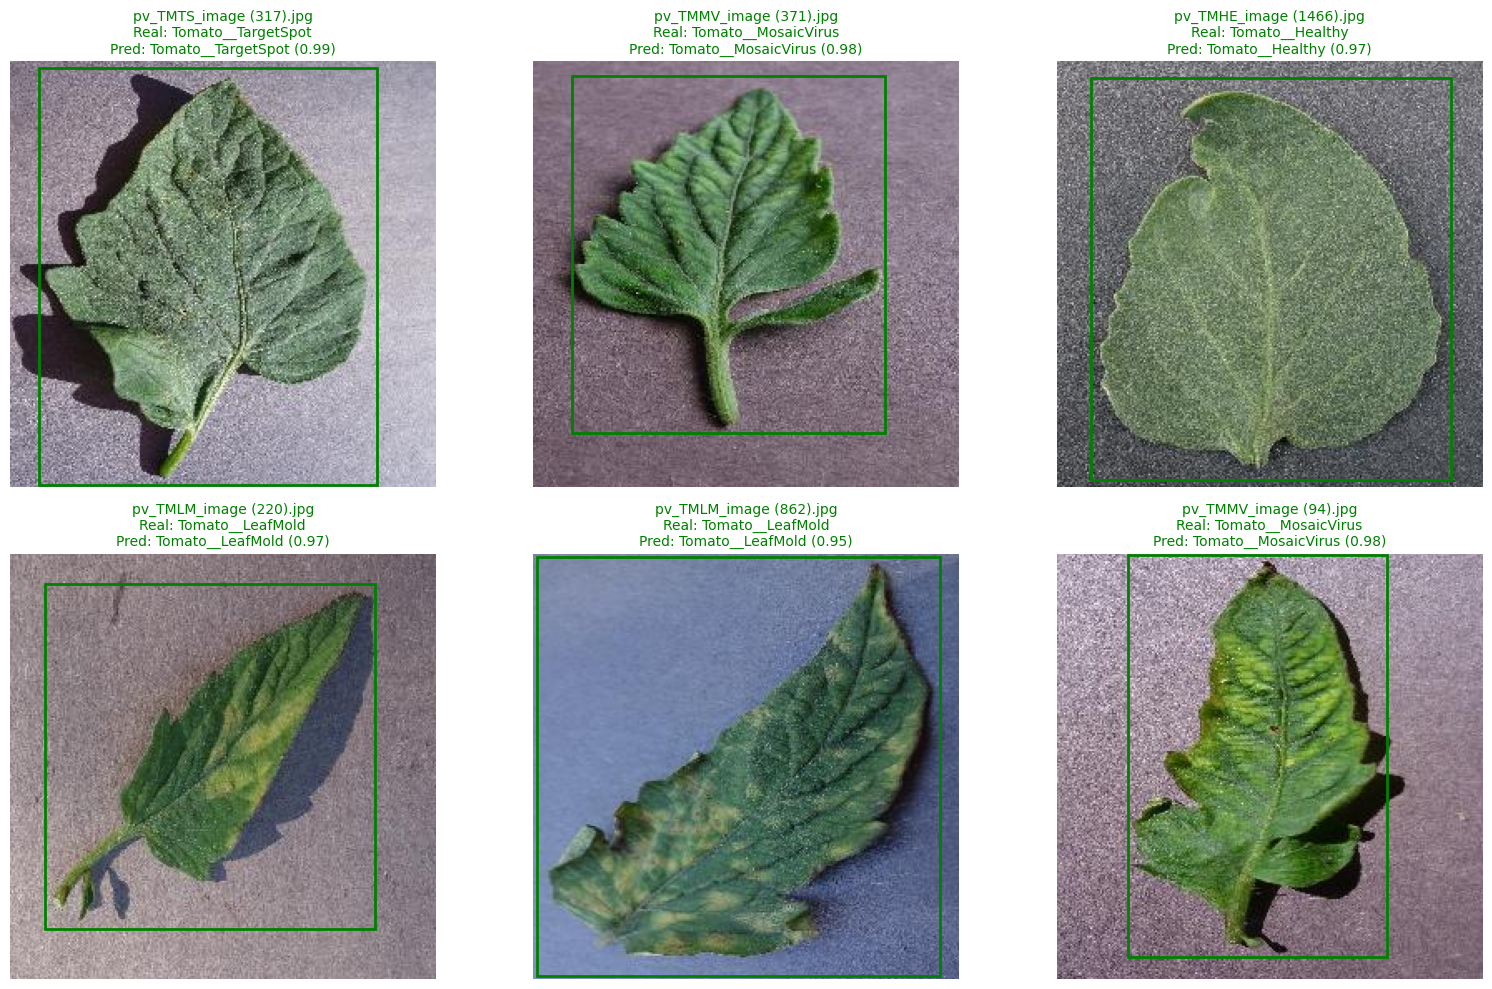

In [ ]:
# ============================================================
# BLOQUE 3: VISUALIZAR IMÁGENES CON REAL VS PREDICCIÓN
# ============================================================

def show_prediction_samples(df, n=6, random_state=42):
    sample_df = df.sample(n=min(n, len(df)), random_state=random_state)

    plt.figure(figsize=(16, 10))

    for i, row in enumerate(sample_df.itertuples(index=False), start=1):
        img_path = Path(row.image_path)
        img = Image.open(img_path).convert("RGB")
        width, height = img.size

        ax = plt.subplot(2, 3, i)
        ax.imshow(img)
        ax.axis("off")

        # Dibujar caja predicha si existe
        if row.pred_box is not None:
            x1, y1, x2, y2 = row.pred_box
            color = "green" if row.correct else "red"

            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor=color,
                facecolor="none"
            )
            ax.add_patch(rect)

        title_color = "green" if row.correct else "red"

        ax.set_title(
            f"{img_path.name}\n"
            f"Real: {row.true_class_name}\n"
            f"Pred: {row.pred_class_name} ({row.pred_conf:.2f})",
            fontsize=10,
            color=title_color
        )

    plt.tight_layout()
    plt.show()

show_prediction_samples(df_preds, n=6, random_state=42)

Cantidad de errores: 15


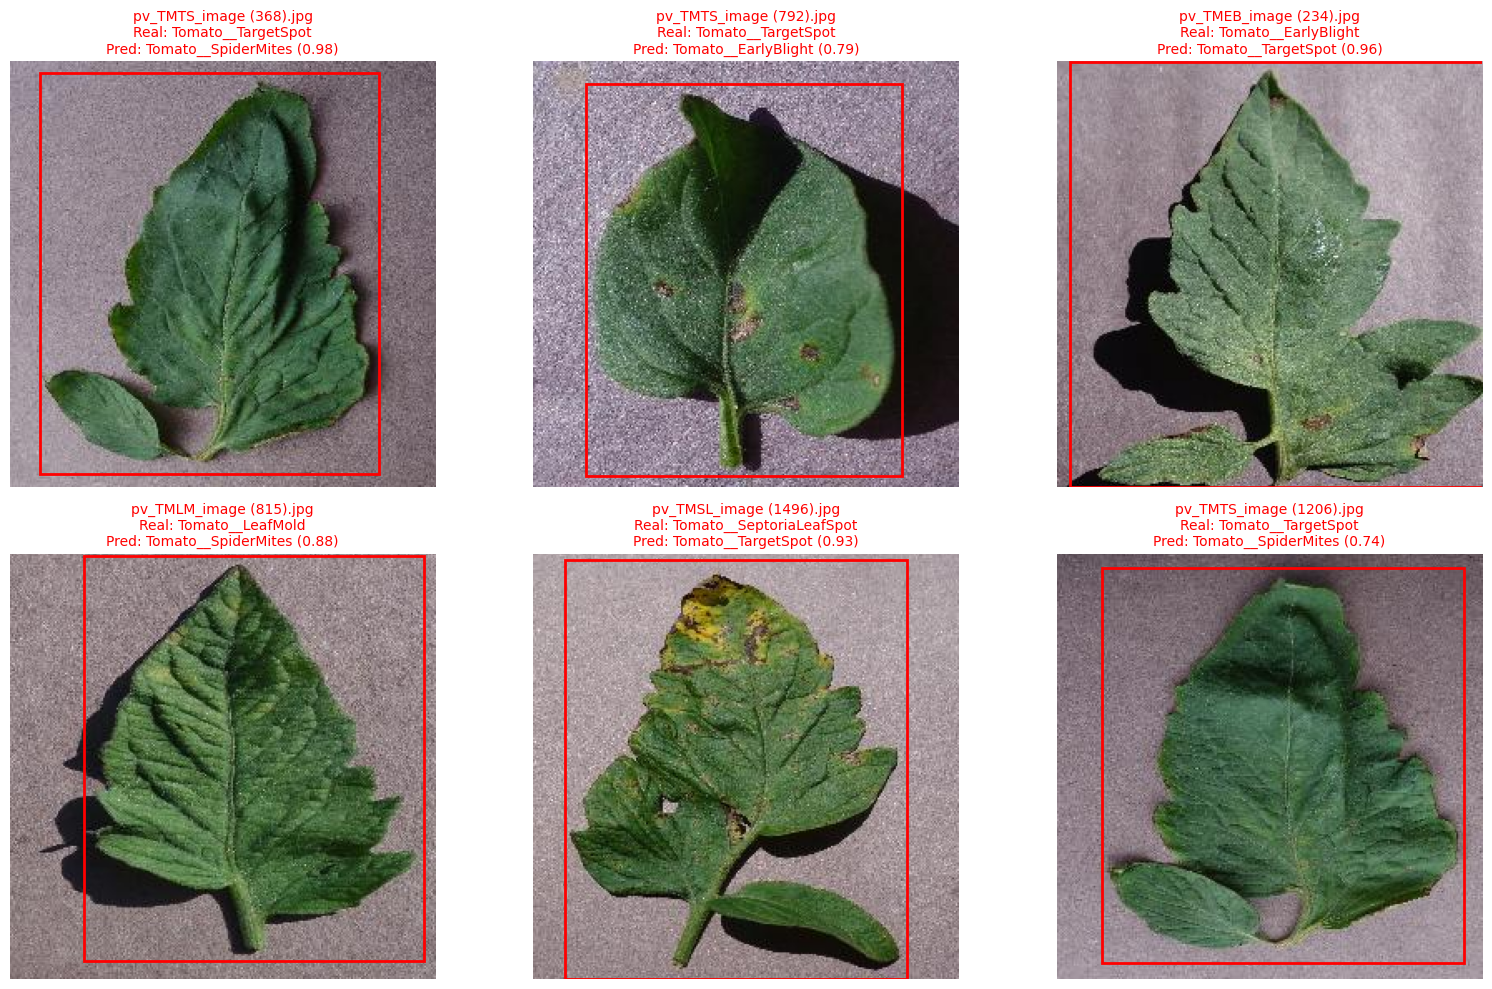

In [ ]:
# ============================================================
# BLOQUE 4: MOSTRAR SOLO PREDICCIONES INCORRECTAS
# ============================================================

df_errors = df_preds[df_preds["correct"] == False].copy()

print("Cantidad de errores:", len(df_errors))

if len(df_errors) > 0:
    show_prediction_samples(df_errors, n=min(6, len(df_errors)), random_state=42)
else:
    print("No se encontraron errores en este subconjunto.")

In [ ]:
# ============================================================
# BLOQUE 6: REPORTE DE CLASIFICACIÓN
# ============================================================

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

                             precision    recall  f1-score   support

      Tomato__BacterialSpot     0.9868    1.0000    0.9934        75
        Tomato__EarlyBlight     0.9474    0.9600    0.9536        75
            Tomato__Healthy     1.0000    1.0000    1.0000        75
         Tomato__LateBlight     1.0000    0.9733    0.9865        75
           Tomato__LeafMold     0.9867    0.9867    0.9867        75
        Tomato__MosaicVirus     1.0000    1.0000    1.0000        75
   Tomato__SeptoriaLeafSpot     0.9863    0.9600    0.9730        75
        Tomato__SpiderMites     0.9375    1.0000    0.9677        75
         Tomato__TargetSpot     0.9589    0.9333    0.9459        75
Tomato__YellowLeafCurlVirus     1.0000    0.9867    0.9933        75

                   accuracy                         0.9800       750
                  macro avg     0.9804    0.9800    0.9800       750
               weighted avg     0.9804    0.9800    0.9800       750



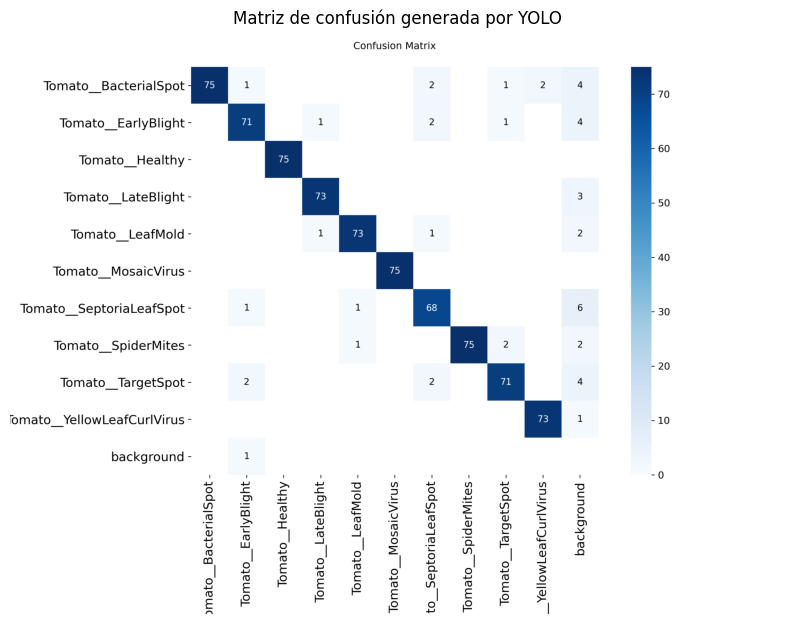

In [ ]:
# ============================================================
# BLOQUE 7: MOSTRAR MATRIZ DE CONFUSIÓN GENERADA POR YOLO
# ============================================================

yolo_cm_path = PROJECT_PATH / "evaluacion_test_yolov8n_balanced_220_75_75" / "confusion_matrix.png"

if yolo_cm_path.exists():
    img_cm = Image.open(yolo_cm_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(img_cm)
    plt.axis("off")
    plt.title("Matriz de confusión generada por YOLO")
    plt.show()
else:
    print("No se encontró confusion_matrix.png en la ruta esperada:")
    print(yolo_cm_path)

# Documentación del Proyecto: Detección de Enfermedades en Hojas de Tomate con YOLOv8n

## 1. Dataset utilizado

Se trabajó con el dataset público **Tomato Leaf Disease**, disponible en Kaggle. Este dataset contiene imágenes de hojas de tomate organizadas para detección con formato YOLO. El archivo de configuración incluía 10 clases:

*   `Tomato__BacterialSpot`
*   `Tomato__EarlyBlight`
*   `Tomato__Healthy`
*   `Tomato__LateBlight`
*   `Tomato__LeafMold`
*   `Tomato__MosaicVirus`
*   `Tomato__SeptoriaLeafSpot`
*   `Tomato__SpiderMites`
*   `Tomato__TargetSpot`
*   `Tomato__YellowLeafCurlVirus`

Inicialmente, el dataset tenía:

| Conjunto original | Cantidad        |
| :---------------- | :-------------- |
| Entrenamiento     | 12.168 imágenes |
| Validación        | 3.041 imágenes  |
| Prueba            | No venía definido |

El dataset original no incluía un conjunto de prueba separado. Por eso se construyó una nueva división metodológica para poder entrenar, validar y probar el modelo de forma más ordenada.

## 2. Revisión y preparación del dataset

Antes de entrenar, se revisó que la estructura fuera compatible con YOLO:

```
archive/
    tomato/
        images/
            train/
            val/
        labels/
            train/
            val/
        data.yaml
```

También se verificó que cada imagen tuviera su respectiva etiqueta `.txt`. El resultado fue:

| Conjunto | Imágenes | Etiquetas |
| :------- | :------- | :-------- |
| Train    | 12.168   | 12.168    |
| Val      | 3.041    | 3.041     |

No se encontraron imágenes sin etiqueta ni etiquetas sin imagen. Además, se visualizaron ejemplos con sus cajas delimitadoras para comprobar que las anotaciones realmente se ubicaban sobre la hoja o región principal de interés.

Este paso fue importante porque la guía exige explicar el conjunto de datos, no solo usarlo directamente.

## 3. Creación de subconjunto balanceado

Entrenar con las 12.168 imágenes completas resultó costoso en Colab. Por eso se tomó una decisión práctica: trabajar con un subconjunto balanceado.

La división final fue:

| Conjunto      | Imágenes por clase | Total |
| :------------ | :----------------- | :---- |
| Entrenamiento | 220                | 2.200 |
| Validación    | 75                 | 750   |
| Prueba        | 75                 | 750   |

Esta decisión fue adecuada porque mantiene representación de las 10 clases y reduce el tiempo de entrenamiento. Además, evita que una enfermedad tenga más peso que otra por desbalance de datos.

Un punto crítico fue la clase `Tomato__MosaicVirus`, que tenía menos imágenes disponibles. Por eso no se usaron 300 imágenes por clase para entrenamiento junto con 75 para validación y 75 para prueba, porque esa división dejaba sin suficientes ejemplos a esa clase en el conjunto de prueba. La división 220/75/75 fue más consistente.

## 4. Modelo seleccionado

El modelo elegido fue **YOLOv8n**, una versión liviana de YOLO.

La elección se justifica por varias razones:

Primero, el dataset está en formato YOLO, por lo que usar un modelo YOLO es coherente con las etiquetas disponibles. Cada etiqueta contiene:

```
class_id x_center y_center width height
```

Esto permite que el modelo aprenda tanto la clase como la ubicación de la hoja o región afectada.

Segundo, YOLO permite hacer detección de objetos en una sola etapa. Es decir, predice simultáneamente la caja delimitadora, la clase y la confianza.

Tercero, YOLOv8n es una versión ligera, adecuada para Colab, porque entrena más rápido y consume menos memoria que versiones más grandes como YOLOv8s o YOLOv8m.

Cuarto, se aplicó **transferencia de aprendizaje**. El modelo no se entrenó desde cero, sino que partió de pesos preentrenados y luego se ajustó al dataset de enfermedades en hojas de tomate.

## 5. Entrenamiento realizado

El entrenamiento se hizo en Google Colab usando GPU Tesla T4. La configuración usada fue:

| Parámetro         | Valor             |
| :---------------- | :---------------- |
| Modelo            | YOLOv8n           |
| Épocas            | 20                |
| Tamaño de imagen  | 640 × 640         |
| Batch size        | 16                |
| Entrenamiento     | 2.200 imágenes    |
| Validación        | 750 imágenes      |
| Prueba            | 750 imágenes      |
| Transfer learning | Sí                |
| Tiempo aproximado | 16,4 minutos      |

La elección de 20 épocas fue razonable porque el modelo mejoró rápidamente y alcanzó métricas altas sin necesidad de extender demasiado el entrenamiento. Además, usar más épocas podía aumentar el riesgo de sobreajuste sin aportar mejoras importantes.

El tamaño de imagen 640 se usó porque es un estándar frecuente en YOLO y conserva suficiente detalle para reconocer manchas, deformaciones, cambios de color y textura en las hojas.

## 6. Resultados en validación

Al finalizar el entrenamiento, el modelo obtuvo en validación:

| Métrica   | Valor |
| :-------- | :---- |
| Precision | 0.971 |
| Recall    | 0.969 |
| mAP50     | 0.986 |
| mAP50-95  | 0.978 |

Esto indica que el modelo aprendió adecuadamente a detectar y clasificar las hojas del conjunto de validación.

La precisión alta indica que, cuando el modelo predice una enfermedad, normalmente acierta. El recall alto indica que detecta la mayoría de los casos reales presentes en las imágenes.

## 7. Evaluación final en prueba

Después del entrenamiento, se evaluó el modelo con el conjunto de prueba independiente de 750 imágenes. Los resultados finales fueron:

| Métrica       | Valor  |
| :------------ | :----- |
| Precision media | 0.9867 |
| Recall medio  | 0.9681 |
| mAP50         | 0.9911 |
| mAP50-95      | 0.9807 |

Estos resultados son fuertes porque el desempeño en prueba se mantuvo muy parecido al de validación. Eso sugiere que el modelo no solo memorizó las imágenes de entrenamiento, sino que generalizó bien sobre imágenes no usadas para entrenar.

## 8. Análisis por clase

El modelo presentó resultados altos en casi todas las clases. Algunas de las mejores clases fueron:

| Clase                       | Resultado destacado |
| :-------------------------- | :------------------ |
| `Tomato__Healthy`           | Recall 1.000        |
| `Tomato__MosaicVirus`       | Recall 1.000        |
| `Tomato__BacterialSpot`     | Recall 1.000        |
| `Tomato__YellowLeafCurlVirus` | Precision 1.000     |

Las clases relativamente más difíciles fueron:

| Clase                     | Punto a vigilar |
| :------------------------ | :-------------- |
| `Tomato__EarlyBlight`     | Recall 0.903    |
| `Tomato__SeptoriaLeafSpot`  | Recall 0.932    |
| `Tomato__TargetSpot`      | Recall 0.928    |

Aunque estos valores siguen siendo buenos, muestran que algunas enfermedades pueden confundirse más que otras, probablemente por similitud visual entre manchas, bordes secos, coloraciones amarillas o deterioro de la hoja.

## 9. Resultados visuales

También se generaron predicciones visuales sobre imágenes de prueba. Cada imagen mostraba:

*   caja delimitadora + clase predicha + porcentaje de confianza

Luego se mejoró la visualización para mostrar de forma más clara:

*   Clase real
*   Clase predicha
*   Confianza
*   Correcta o incorrecta

Esto es importante porque la guía no pide solamente métricas numéricas, sino también explicación de resultados obtenidos en imágenes.

La interpretación visual correcta es:

El modelo detecta la hoja o región anotada y la clasifica como sana o como una de las enfermedades del tomate. En la mayoría de los ejemplos, las cajas cubren la hoja completa o la región principal de la hoja, no necesariamente cada mancha individual.

Esta aclaración es clave para no exagerar el alcance del proyecto.

## 10. Matriz de confusión

Se generó una matriz de confusión para analizar los aciertos y errores por clase. En la matriz de YOLO aparece una categoría adicional llamada `background`.

Esa clase no pertenece al dataset. YOLO la usa para representar errores de detección:

*   Si una clase se confunde con `background`, significa que que el modelo no detectó algo que sí estaba anotado.
*   Si `background` se confunde con una clase, significa que el modelo detectó algo donde no había una anotación correspondiente.

La matriz de confusión permite identificar si los errores se concentran en enfermedades específicas. En este caso, por los resultados obtenidos, se esperaría una diagonal principal fuerte, con pocos errores fuera de la diagonal.

In [ ]:
# ============================================================
# INSTALAR KAGGLE
# ============================================================

!pip install kaggle -q

In [ ]:
# ============================================================
# DESCARGAR DATASET TOMATO LEAF DISEASE
# ============================================================

from pathlib import Path

ARCHIVE_DIR = Path("/content/drive/MyDrive/archive")
ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)

!kaggle datasets download -d yusufmurtaza01/tomato-leaf-disease -p /content/drive/MyDrive/archive --unzip

Dataset URL: https://www.kaggle.com/datasets/yusufmurtaza01/tomato-leaf-disease
License(s): CC0-1.0
100% 445M/445M [00:09<00:00, 50.5MB/s]



In [ ]:
# ============================================================
# VERIFICAR ESTRUCTURA DEL DATASET DESCARGADO
# ============================================================

from pathlib import Path

DATASET_ORIGINAL = Path("/content/drive/MyDrive/archive/tomato")

print("DATASET_ORIGINAL:", DATASET_ORIGINAL)
print("Existe:", DATASET_ORIGINAL.exists())

print("images/train:", (DATASET_ORIGINAL / "images" / "train").exists())
print("images/val:", (DATASET_ORIGINAL / "images" / "val").exists())
print("labels/train:", (DATASET_ORIGINAL / "labels" / "train").exists())
print("labels/val:", (DATASET_ORIGINAL / "labels" / "val").exists())

DATASET_ORIGINAL: /content/drive/MyDrive/archive/tomato
Existe: True
images/train: True
images/val: True
labels/train: True
labels/val: True


In [ ]:
# ============================================================
# BUSCAR CARPETAS DE PREDICCIONES GUARDADAS
# ============================================================

from pathlib import Path

PROJECT_PATH = Path("/content/drive/MyDrive/proyecto_tomato_yolo")

for folder in PROJECT_PATH.rglob("*predicciones*"):
    if folder.is_dir():
        print(folder)

/content/drive/MyDrive/proyecto_tomato_yolo/predicciones_test_yolov8n_balanced


In [ ]:
# ============================================================
# DEFINIR CARPETA DE PREDICCIONES YOLOv8n
# ============================================================

PRED_DIR_8N = Path("/content/drive/MyDrive/proyecto_tomato_yolo/predicciones_test_yolov8n_balanced")

print("Existe PRED_DIR_8N:", PRED_DIR_8N.exists())
print("Cantidad de archivos:", len(list(PRED_DIR_8N.glob("*"))))

Existe PRED_DIR_8N: True
Cantidad de archivos: 750


In [ ]:
# ============================================================
# RECONSTRUIR TEST A PARTIR DE IMÁGENES PREDICHAS POR YOLOv8n
# ============================================================

from pathlib import Path
from collections import defaultdict
import random

DATASET_ORIGINAL = Path("/content/drive/MyDrive/archive/tomato")

TRAIN_IMAGES_DIR = DATASET_ORIGINAL / "images" / "train"
VAL_IMAGES_DIR = DATASET_ORIGINAL / "images" / "val"

SUBSET_DIR = Path("/content/drive/MyDrive/archive/tomato_subset_recovered_for_comparison")
SUBSET_DIR.mkdir(parents=True, exist_ok=True)

image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

# Todas las imágenes originales disponibles
all_original_images = []

for images_dir in [TRAIN_IMAGES_DIR, VAL_IMAGES_DIR]:
    all_original_images.extend([
        f for f in images_dir.iterdir()
        if f.suffix.lower() in image_extensions
    ])

# Nombres de imágenes guardadas en predicciones YOLOv8n
predicted_names = {
    f.name for f in PRED_DIR_8N.iterdir()
    if f.suffix.lower() in image_extensions
}

# Reconstruir imágenes de test por nombre
test_images = [
    img for img in all_original_images
    if img.name in predicted_names
]

print("Imágenes predichas encontradas:", len(predicted_names))
print("Imágenes test reconstruidas:", len(test_images))

if len(test_images) == 0:
    raise ValueError("No se pudo reconstruir el test. Revisa la ruta PRED_DIR_8N.")

Imágenes predichas encontradas: 750
Imágenes test reconstruidas: 750


In [ ]:
# ============================================================
# CREAR TRAIN / VAL EXCLUYENDO EL TEST RECUPERADO
# ============================================================

N_TRAIN_PER_CLASS = 220
N_VAL_PER_CLASS = 75

random.seed(42)

code_to_class = {
    "TMBS": 0,
    "TMEB": 1,
    "TMB": 1,
    "TMHE": 2,
    "TMLB": 3,
    "TMLM": 4,
    "TMMV": 5,
    "TMSL": 6,
    "TMSM": 7,
    "TMTS": 8,
    "TMYC": 9,
}

def get_class_from_filename(filename):
    for code, class_id in code_to_class.items():
        if code in filename:
            return class_id
    return None

test_set_names = {img.name for img in test_images}

remaining_images = [
    img for img in all_original_images
    if img.name not in test_set_names
]

grouped = defaultdict(list)

for img_path in remaining_images:
    class_id = get_class_from_filename(img_path.name)
    if class_id is not None:
        grouped[class_id].append(img_path)

print("Distribución disponible excluyendo test:")
for class_id in range(10):
    print(f"Clase {class_id}: {len(grouped[class_id])}")

subset_train = []
subset_val = []

for class_id in range(10):
    images = grouped[class_id].copy()
    random.shuffle(images)

    required = N_TRAIN_PER_CLASS + N_VAL_PER_CLASS

    if len(images) < required:
        raise ValueError(
            f"Clase {class_id} tiene {len(images)} imágenes disponibles. "
            f"Se requieren {required}."
        )

    subset_train.extend(images[:N_TRAIN_PER_CLASS])
    subset_val.extend(images[N_TRAIN_PER_CLASS:N_TRAIN_PER_CLASS + N_VAL_PER_CLASS])

print("\nConteos:")
print("Train:", len(subset_train))
print("Val:", len(subset_val))
print("Test:", len(test_images))

Distribución disponible excluyendo test:
Clase 0: 1822
Clase 1: 925
Clase 2: 1516
Clase 3: 1816
Clase 4: 877
Clase 5: 298
Clase 6: 1696
Clase 7: 1601
Clase 8: 1329
Clase 9: 1895

Conteos:
Train: 2200
Val: 750
Test: 750


In [ ]:
# ============================================================
# GUARDAR SPLITS RECUPERADOS
# ============================================================

train_txt = SUBSET_DIR / "train.txt"
val_txt = SUBSET_DIR / "val.txt"
test_txt = SUBSET_DIR / "test.txt"

def save_list(image_list, txt_path):
    with open(txt_path, "w", encoding="utf-8") as f:
        for img_path in image_list:
            f.write(str(img_path) + "\n")

save_list(subset_train, train_txt)
save_list(subset_val, val_txt)
save_list(test_images, test_txt)

yaml_content = f"""
train: {train_txt}
val: {val_txt}
test: {test_txt}

nc: 10
names:
  - Tomato__BacterialSpot
  - Tomato__EarlyBlight
  - Tomato__Healthy
  - Tomato__LateBlight
  - Tomato__LeafMold
  - Tomato__MosaicVirus
  - Tomato__SeptoriaLeafSpot
  - Tomato__SpiderMites
  - Tomato__TargetSpot
  - Tomato__YellowLeafCurlVirus
"""

yaml_path = SUBSET_DIR / "data.yaml"

with open(yaml_path, "w", encoding="utf-8") as f:
    f.write(yaml_content.strip())

print("Archivos creados:")
print("train_txt:", train_txt, train_txt.exists())
print("val_txt:", val_txt, val_txt.exists())
print("test_txt:", test_txt, test_txt.exists())
print("yaml_path:", yaml_path, yaml_path.exists())

print("\nConteos:")
print("Train:", sum(1 for _ in open(train_txt, "r", encoding="utf-8")))
print("Val:", sum(1 for _ in open(val_txt, "r", encoding="utf-8")))
print("Test:", sum(1 for _ in open(test_txt, "r", encoding="utf-8")))

Archivos creados:
train_txt: /content/drive/MyDrive/archive/tomato_subset_recovered_for_comparison/train.txt True
val_txt: /content/drive/MyDrive/archive/tomato_subset_recovered_for_comparison/val.txt True
test_txt: /content/drive/MyDrive/archive/tomato_subset_recovered_for_comparison/test.txt True
yaml_path: /content/drive/MyDrive/archive/tomato_subset_recovered_for_comparison/data.yaml True

Conteos:
Train: 2200
Val: 750
Test: 750


In [ ]:
# ============================================================
# VERIFICAR INTERSECCIONES
# ============================================================

def read_txt_paths(txt_path):
    with open(txt_path, "r", encoding="utf-8") as f:
        return set(line.strip() for line in f if line.strip())

train_set = read_txt_paths(train_txt)
val_set = read_txt_paths(val_txt)
test_set = read_txt_paths(test_txt)

print("Intersección train-val:", len(train_set & val_set))
print("Intersección train-test:", len(train_set & test_set))
print("Intersección val-test:", len(val_set & test_set))

Intersección train-val: 0
Intersección train-test: 0
Intersección val-test: 0


In [ ]:
# ============================================================
# ENTRENAR YOLO11s
# ============================================================

!pip install -U ultralytics -q

import torch
from ultralytics import YOLO
from pathlib import Path

PROJECT_PATH = Path("/content/drive/MyDrive/proyecto_tomato_yolo")
PROJECT_PATH.mkdir(parents=True, exist_ok=True)

print("GPU disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model_11s = YOLO("yolo11s.pt")

results_11s = model_11s.train(
    data=str(yaml_path),
    epochs=20,
    imgsz=640,
    batch=8,
    project=str(PROJECT_PATH),
    name="tomato_yolo11s_comparison_same_test",
    pretrained=True,
    patience=5,
    save=True,
    plots=True
)

GPU disponible: True
GPU: Tesla T4
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/archive/tomato_subset_recovered_for_comparison/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tomato_yolo11s_com

In [ ]:
# ============================================================
# EVALUAR YOLO11s EN TEST
# ============================================================

best_model_11s_path = PROJECT_PATH / "tomato_yolo11s_comparison_same_test" / "weights" / "best.pt"

model_11s_trained = YOLO(str(best_model_11s_path))

test_metrics_11s = model_11s_trained.val(
    data=str(yaml_path),
    split="test",
    imgsz=640,
    plots=True,
    project=str(PROJECT_PATH),
    name="evaluacion_test_yolo11s_comparison_same_test"
)

print("YOLO11s - Test")
print("Precision:", test_metrics_11s.box.mp)
print("Recall:", test_metrics_11s.box.mr)
print("mAP50:", test_metrics_11s.box.map50)
print("mAP50-95:", test_metrics_11s.box.map)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,416,670 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.3 ms, read: 6.9±2.1 MB/s, size: 17.9 KB)
val: Scanning /content/drive/MyDrive/archive/tomato/labels/train... 750 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 750/750 112.2it/s 6.7s
val: New cache created: /content/drive/MyDrive/archive/tomato/labels/train.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 3.7it/s 12.8s
                   all        750        751      0.979      0.979      0.993      0.984
 Tomato__BacterialSpot         75         75      0.928          1      0.995      0.995
   Tomato__EarlyBlight         75         76      0.969      0.947      0.983      0.957
       Tomato__Healthy         75         75       0.99          1      0.995      0.995
    Tomato__LateBlight         75         

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# MÉTRICAS GLOBALES
# ============================================================

metrics_df = pd.DataFrame({
    "Modelo": ["YOLOv8n", "YOLO11s"],
    "Precision": [0.9867, 0.9789238974],
    "Recall": [0.9681, 0.9786317176],
    "mAP50": [0.9911, 0.9927085308],
    "mAP50-95": [0.9807, 0.9840545502]
})

metrics_df

,Modelo,Precision,Recall,mAP50,mAP50-95
0,YOLOv8n,0.986700,0.968100,0.991100,0.980700
1,YOLO11s,0.978924,0.978632,0.992709,0.984055


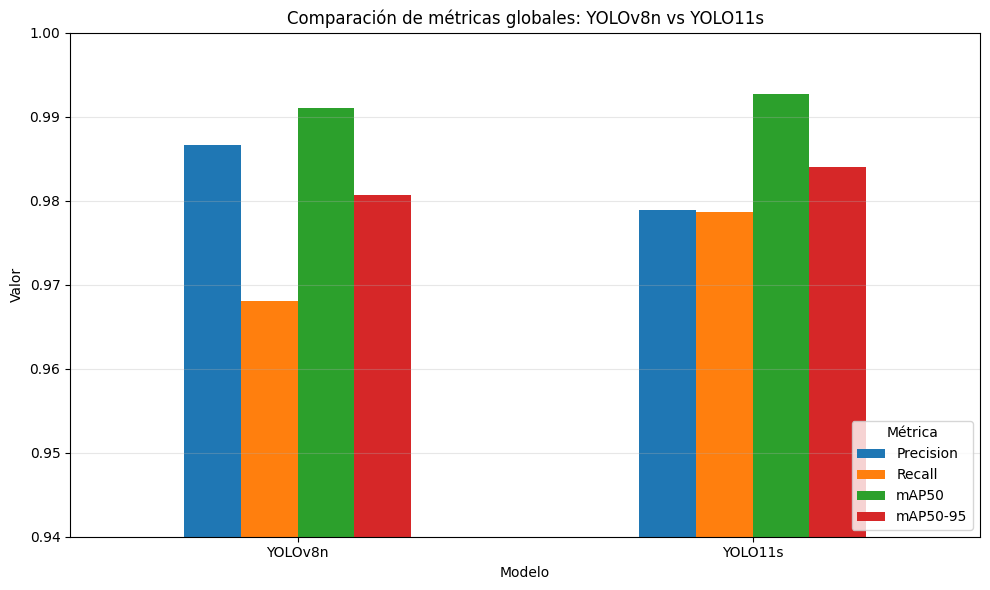

In [ ]:
# ============================================================
# GRÁFICA 1: COMPARACIÓN DE MÉTRICAS GLOBALES
# ============================================================

metrics_plot = metrics_df.set_index("Modelo")

ax = metrics_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Comparación de métricas globales: YOLOv8n vs YOLO11s")
plt.ylabel("Valor")
plt.ylim(0.94, 1.00)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Métrica", loc="lower right")
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/proyecto_tomato_yolo/comparacion_metricas_globales.png", dpi=300)
plt.show()

In [ ]:
# ============================================================
# COSTO COMPUTACIONAL
# ============================================================

cost_df = pd.DataFrame({
    "Modelo": ["YOLOv8n", "YOLO11s"],
    "Parámetros_M": [3.0, 9.4],
    "GFLOPs": [8.1, 21.3],
    "Tamaño_MB": [6.2, 19.2],
    "Entrenamiento_min": [16.4, 23.5],
    "Inferencia_ms": [4.2, 10.0]
})

cost_df

,Modelo,Parámetros_M,GFLOPs,Tamaño_MB,Entrenamiento_min,Inferencia_ms
0,YOLOv8n,3.0,8.1,6.2,16.4,4.2
1,YOLO11s,9.4,21.3,19.2,23.5,10.0


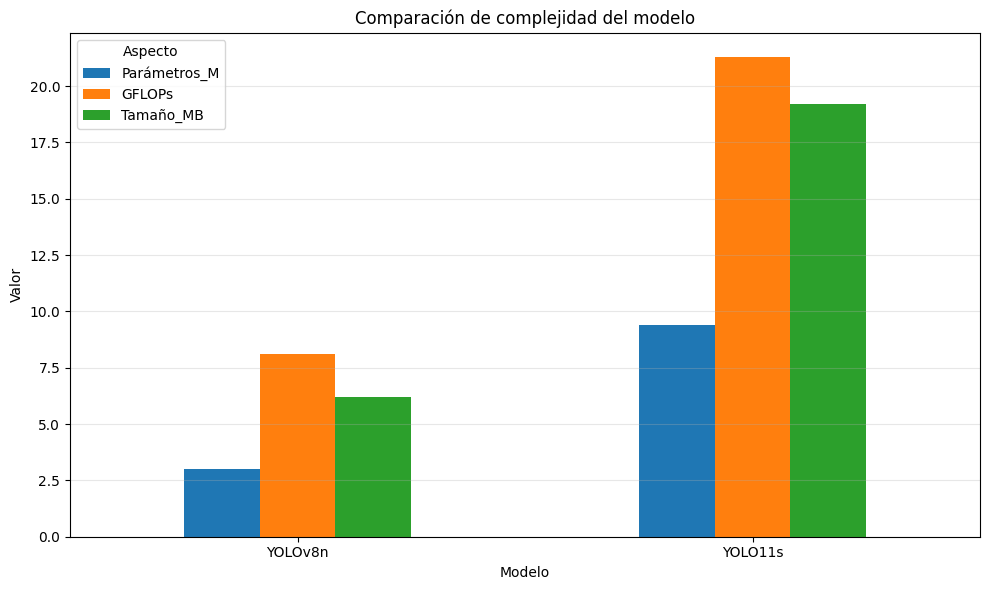

In [ ]:
# ============================================================
# GRÁFICA 3: COMPLEJIDAD DEL MODELO
# ============================================================

complexity_df = cost_df.set_index("Modelo")[["Parámetros_M", "GFLOPs", "Tamaño_MB"]]

ax = complexity_df.plot(kind="bar", figsize=(10, 6))

plt.title("Comparación de complejidad del modelo")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Aspecto")
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/proyecto_tomato_yolo/comparacion_complejidad_modelos.png", dpi=300)
plt.show()

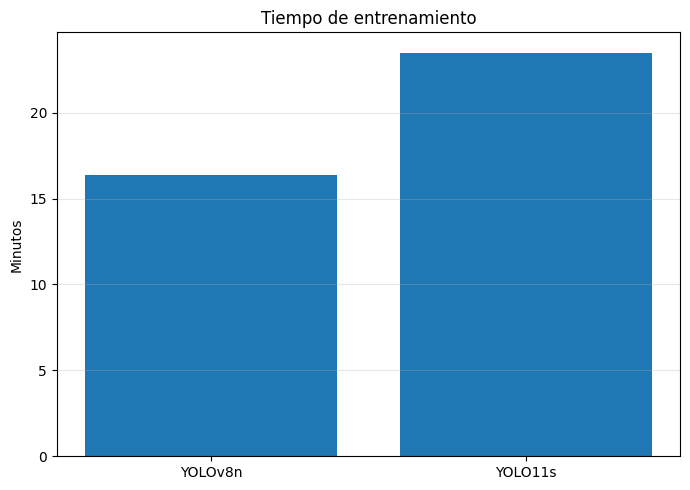

In [ ]:
# ============================================================
# GRÁFICA 4: TIEMPO DE ENTRENAMIENTO
# ============================================================

plt.figure(figsize=(7, 5))
plt.bar(cost_df["Modelo"], cost_df["Entrenamiento_min"])

plt.title("Tiempo de entrenamiento")
plt.ylabel("Minutos")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/proyecto_tomato_yolo/comparacion_tiempo_entrenamiento.png", dpi=300)
plt.show()

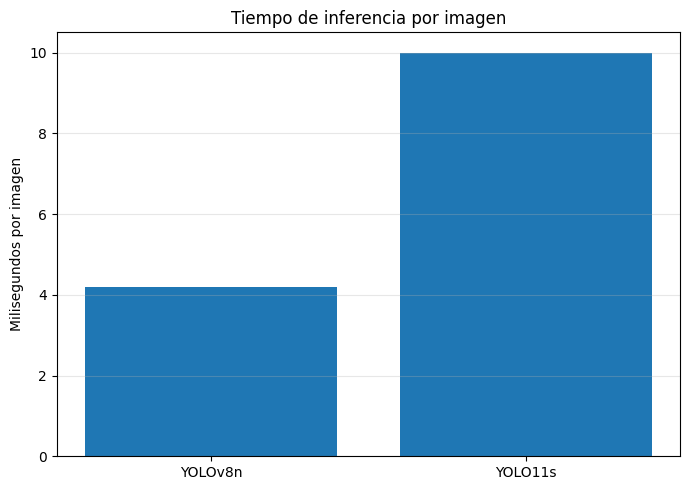

In [ ]:
# ============================================================
# GRÁFICA 5: TIEMPO DE INFERENCIA
# ============================================================

plt.figure(figsize=(7, 5))
plt.bar(cost_df["Modelo"], cost_df["Inferencia_ms"])

plt.title("Tiempo de inferencia por imagen")
plt.ylabel("Milisegundos por imagen")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/proyecto_tomato_yolo/comparacion_tiempo_inferencia.png", dpi=300)
plt.show()

In [ ]:
# ============================================================
# MÉTRICAS POR CLASE - RECALL
# ============================================================

class_df = pd.DataFrame({
    "Clase": [
        "BacterialSpot",
        "EarlyBlight",
        "Healthy",
        "LateBlight",
        "LeafMold",
        "MosaicVirus",
        "SeptoriaLeafSpot",
        "SpiderMites",
        "TargetSpot",
        "YellowLeafCurlVirus"
    ],
    "Recall_YOLOv8n": [
        1.000,
        0.903,
        1.000,
        0.956,
        0.976,
        1.000,
        0.932,
        1.000,
        0.928,
        0.987
    ],
    "Recall_YOLO11s": [
        1.000,
        0.947,
        1.000,
        0.953,
        0.987,
        1.000,
        0.958,
        1.000,
        0.947,
        0.994
    ]
})

class_df["Diferencia_Recall"] = class_df["Recall_YOLO11s"] - class_df["Recall_YOLOv8n"]

class_df

,Clase,Recall_YOLOv8n,Recall_YOLO11s,Diferencia_Recall
0,BacterialSpot,1.000,1.000,0.000
1,EarlyBlight,0.903,0.947,0.044
2,Healthy,1.000,1.000,0.000
3,LateBlight,0.956,0.953,-0.003
4,LeafMold,0.976,0.987,0.011
5,MosaicVirus,1.000,1.000,0.000
6,SeptoriaLeafSpot,0.932,0.958,0.026
7,SpiderMites,1.000,1.000,0.000
8,TargetSpot,0.928,0.947,0.019
9,YellowLeafCurlVirus,0.987,0.994,0.007


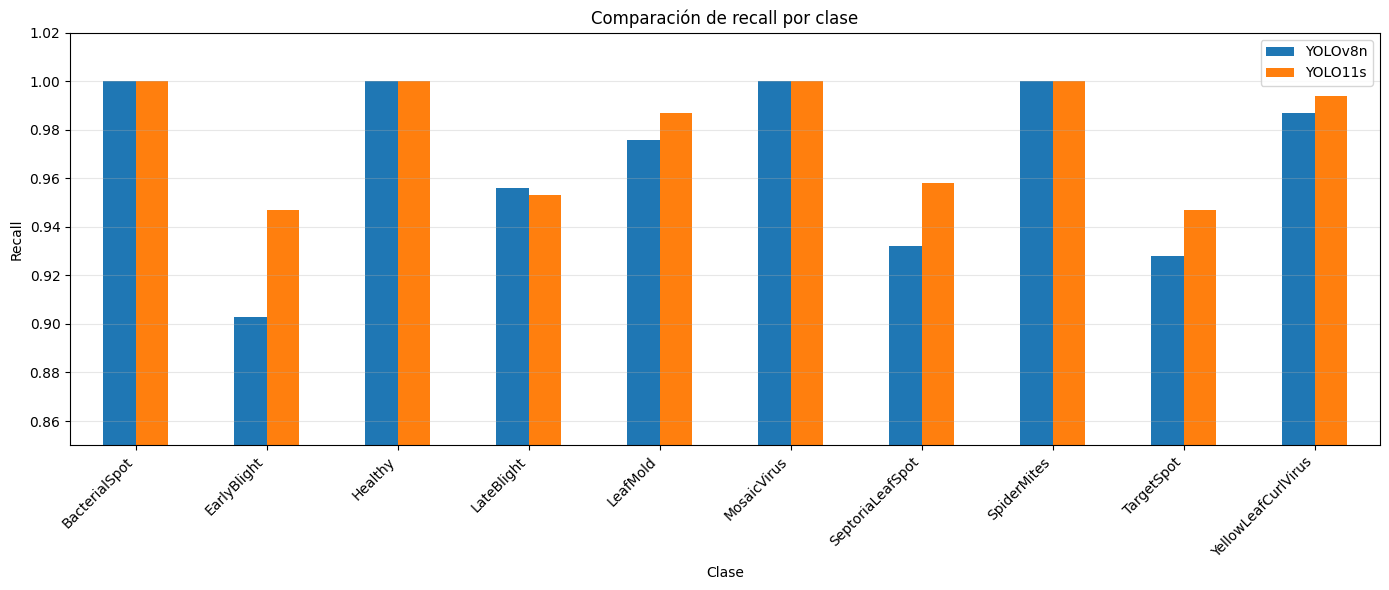

In [ ]:
# ============================================================
# GRÁFICA 6: RECALL POR CLASE
# ============================================================

plot_df = class_df.set_index("Clase")[["Recall_YOLOv8n", "Recall_YOLO11s"]]

ax = plot_df.plot(kind="bar", figsize=(14, 6))

plt.title("Comparación de recall por clase")
plt.ylabel("Recall")
plt.ylim(0.85, 1.02)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(["YOLOv8n", "YOLO11s"])
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/proyecto_tomato_yolo/comparacion_recall_por_clase.png", dpi=300)
plt.show()

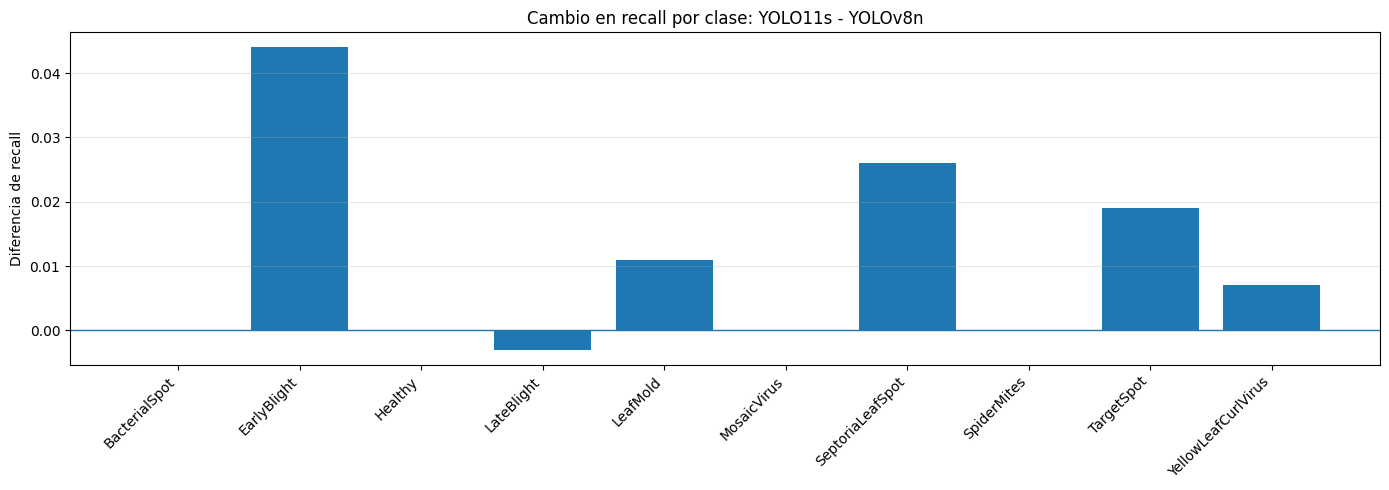

In [ ]:
# ============================================================
# GRÁFICA 7: DIFERENCIA DE RECALL POR CLASE
# ============================================================

plt.figure(figsize=(14, 5))
plt.bar(class_df["Clase"], class_df["Diferencia_Recall"])
plt.axhline(0, linewidth=1)

plt.title("Cambio en recall por clase: YOLO11s - YOLOv8n")
plt.ylabel("Diferencia de recall")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/proyecto_tomato_yolo/diferencia_recall_por_clase.png", dpi=300)
plt.show()

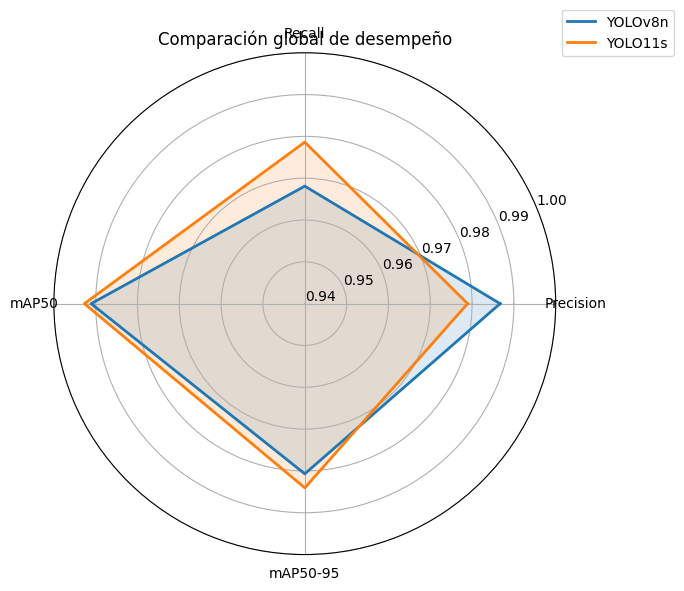

In [ ]:
# ============================================================
# GRÁFICA 8: RADAR DE MÉTRICAS GLOBALES
# ============================================================

labels = ["Precision", "Recall", "mAP50", "mAP50-95"]

yolov8n_values = [0.9867, 0.9681, 0.9911, 0.9807]
yolo11s_values = [0.9789238974, 0.9786317176, 0.9927085308, 0.9840545502]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()

yolov8n_values += yolov8n_values[:1]
yolo11s_values += yolo11s_values[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

ax.plot(angles, yolov8n_values, linewidth=2, label="YOLOv8n")
ax.fill(angles, yolov8n_values, alpha=0.15)

ax.plot(angles, yolo11s_values, linewidth=2, label="YOLO11s")
ax.fill(angles, yolo11s_values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.set_ylim(0.94, 1.00)
ax.set_title("Comparación global de desempeño")
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10))

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/proyecto_tomato_yolo/radar_comparacion_modelos.png", dpi=300)
plt.show()

In [ ]:
# ============================================================
# TABLA FINAL COMPARATIVA
# ============================================================

final_comparison = pd.DataFrame({
    "Aspecto": [
        "Precision",
        "Recall",
        "mAP50",
        "mAP50-95",
        "Parámetros",
        "GFLOPs",
        "Tamaño del modelo",
        "Tiempo de entrenamiento",
        "Inferencia por imagen",
        "Conclusión"
    ],
    "YOLOv8n": [
        "0.9867",
        "0.9681",
        "0.9911",
        "0.9807",
        "3.0 M",
        "8.1",
        "6.2 MB",
        "16.4 min",
        "4.2 ms",
        "Más liviano y eficiente"
    ],
    "YOLO11s": [
        "0.9789",
        "0.9786",
        "0.9927",
        "0.9841",
        "9.4 M",
        "21.3",
        "19.2 MB",
        "23.5 min",
        "10.0 ms",
        "Mayor recall y mAP"
    ]
})

final_comparison

,Aspecto,YOLOv8n,YOLO11s
0,Precision,0.9867,0.9789
1,Recall,0.9681,0.9786
2,mAP50,0.9911,0.9927
3,mAP50-95,0.9807,0.9841
4,Parámetros,3.0 M,9.4 M
5,GFLOPs,8.1,21.3
6,Tamaño del modelo,6.2 MB,19.2 MB
7,Tiempo de entrenamiento,16.4 min,23.5 min
8,Inferencia por imagen,4.2 ms,10.0 ms
9,Conclusión,Más liviano y eficiente,Mayor recall y mAP


## Conclusión de la Comparación YOLOv8n vs YOLO11s

### 1. Resultados comparativos en test

| Métrica             | YOLOv8n | YOLO11s | Diferencia                |
| :------------------ | :------ | :------ | :------------------------ |
| Precision           | 0.9867  | 0.9789  | YOLOv8n mejor             |
| Recall              | 0.9681  | 0.9786  | YOLO11s mejor             |
| mAP50               | 0.9911  | 0.9927  | YOLO11s ligeramente mejor |
| mAP50-95            | 0.9807  | 0.9841  | YOLO11s ligeramente mejor |
| Inferencia por imagen | 4.2 ms  | 10.0 ms | YOLOv8n más rápido        |
| Parámetros          | 3.0 M   | 9.4 M   | YOLOv8n más liviano       |
| GFLOPs              | 8.1     | 21.3    | YOLOv8n menos costoso     |
| Tamaño del modelo   | 6.2 MB  | 19.2 MB | YOLOv8n más liviano       |
| Tiempo entrenamiento| 16.4 min| 23.5 min| YOLOv8n más rápido        |

En el log de YOLO11s se observa que el modelo final tuvo 9.416.670 parámetros, 21.3 GFLOPs, un tamaño de pesos de 19.2 MB y un entrenamiento de 0.391 horas, además de métricas altas al finalizar la validación: precision 0.972, recall 0.975, mAP50 0.989 y mAP50-95 0.978.

### 2. Interpretación objetiva

YOLO11s sí mejoró algunas métricas, especialmente:

*   **Recall**: 0.9681 → 0.9786
*   **mAP50**: 0.9911 → 0.9927
*   **mAP50-95**: 0.9807 → 0.9841

Esto indica que YOLO11s detectó una proporción ligeramente mayor de objetos reales y tuvo una localización un poco más precisa.

Sin embargo, YOLOv8n tuvo mejor precision:

*   **YOLOv8n**: 0.9867
*   **YOLO11s**: 0.9789

Eso significa que YOLOv8n fue ligeramente más conservador o más exacto en sus detecciones positivas, mientras que YOLO11s recuperó más casos reales, pero con una pequeña reducción en precisión.

### 3. Comparación costo-beneficio

La mejora de YOLO11s existe, pero es pequeña. El aumento de costo computacional sí es claro:

*   YOLO11s tiene más del triple de parámetros que YOLOv8n.
*   YOLO11s pesa aproximadamente tres veces más.
*   YOLO11s fue más lento en inferencia.
*   YOLO11s tardó más en entrenar.

Por tanto, la conclusión no debería ser simplemente “YOLO11s es mejor”. Una conclusión más correcta sería:

YOLO11s obtuvo mejores valores de recall, mAP50 y mAP50-95, lo que indica una ligera mejora en capacidad de detección y localización. Sin embargo, esta mejora fue pequeña frente al aumento considerable en tamaño, costo computacional y tiempo de inferencia. Por eso, si se busca eficiencia y despliegue en equipos con recursos limitados, YOLOv8n sigue siendo una opción más conveniente. Si se prioriza la máxima detección posible, YOLO11s puede ser preferible.

### 4. Análisis por clase de YOLO11s

En el test, YOLO11s tuvo muy buenos resultados por clase:

| Clase                     | Precision | Recall | mAP50-95 |
| :------------------------ | :-------- | :----- | :------- |
| BacterialSpot             | 0.928     | 1.000  | 0.995    |
| EarlyBlight               | 0.969     | 0.947  | 0.957    |
| Healthy                   | 0.990     | 1.000  | 0.995    |
| LateBlight                | 1.000     | 0.953  | 0.979    |
| LeafMold                  | 0.997     | 0.987  | 0.975    |
| MosaicVirus               | 1.000     | 1.000  | 0.993    |
| SeptoriaLeafSpot          | 1.000     | 0.958  | 0.978    |
| SpiderMites               | 0.967     | 1.000  | 0.990    |
| TargetSpot                | 0.951     | 0.947  | 0.985    |
| YellowLeafCurlVirus       | 0.987     | 0.994  | 0.995    |

Las clases más débiles siguen siendo relativamente similares a las del modelo anterior: EarlyBlight, TargetSpot y algunas clases con manchas visualmente parecidas. Esto tiene sentido porque esas enfermedades pueden compartir patrones de daño: manchas oscuras, bordes amarillentos o necrosis parcial.

Para complementar el análisis, se comparó el modelo base YOLOv8n con YOLO11s, una versión más reciente y robusta. Ambos modelos fueron entrenados bajo condiciones comparables, usando el mismo subconjunto balanceado, el mismo tamaño de imagen y el mismo número de épocas. En el conjunto de prueba, YOLOv8n obtuvo una precision de 0.9867, recall de 0.9681, mAP50 de 0.9911 y mAP50-95 de 0.9807. Por su parte, YOLO11s obtuvo una precision de 0.9789, recall de 0.9786, mAP50 de 0.9927 y mAP50-95 de 0.9841.

Los resultados muestran que YOLO11s mejoró ligeramente el recall y las métricas mAP, lo cual indica una mejor capacidad general de detección y localización. Sin embargo, YOLOv8n mantuvo una precision superior y fue considerablemente más liviano y rápido. Por tanto, YOLO11s ofrece una mejora marginal en desempeño, pero a costa de mayor tamaño del modelo, mayor tiempo de entrenamiento y mayor tiempo de inferencia.